In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
# import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# --- KHỞI TẠO CẤU HÌNH & ĐỌC DỮ LIỆU ---
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Đọc file dữ liệu thực tế
df = pd.read_csv("preprocess_1_new.csv")


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      445 non-null    int64  
 1   Name            445 non-null    str    
 2   Screen Size     445 non-null    float64
 3   Display         445 non-null    str    
 4   NFC             445 non-null    int64  
 5   Battery         445 non-null    float64
 6   Price           445 non-null    float64
 7   Brand           445 non-null    str    
 8   OS_Name         445 non-null    str    
 9   OS_Version      445 non-null    float64
 10  antutu_11       445 non-null    float64
 11  clock           445 non-null    float64
 12  Chipset_name    445 non-null    str    
 13  Chipset_gen     445 non-null    str    
 14  gpu_name        445 non-null    str    
 15  gpu_gen         445 non-null    str    
 16  Refresh Rate    445 non-null    float64
 17  total_cores     445 non-null    float64
 18  m

In [3]:
NUM_COLS = df.select_dtypes(include=np.number).columns.tolist()

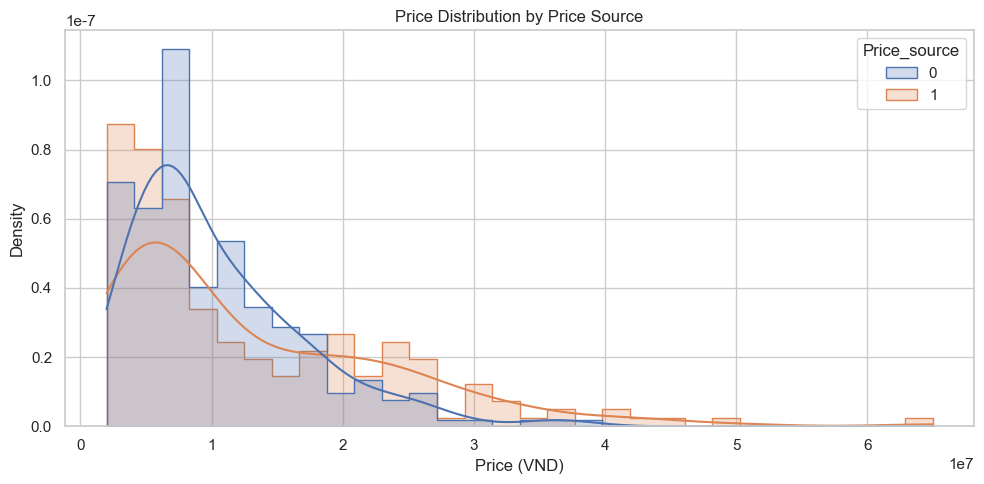

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df, x='Price', hue='Price_source', bins=30, kde=True, stat='density',
    common_norm=False,
    element='step'
)

plt.title("Price Distribution by Price Source")
plt.xlabel("Price (VND)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

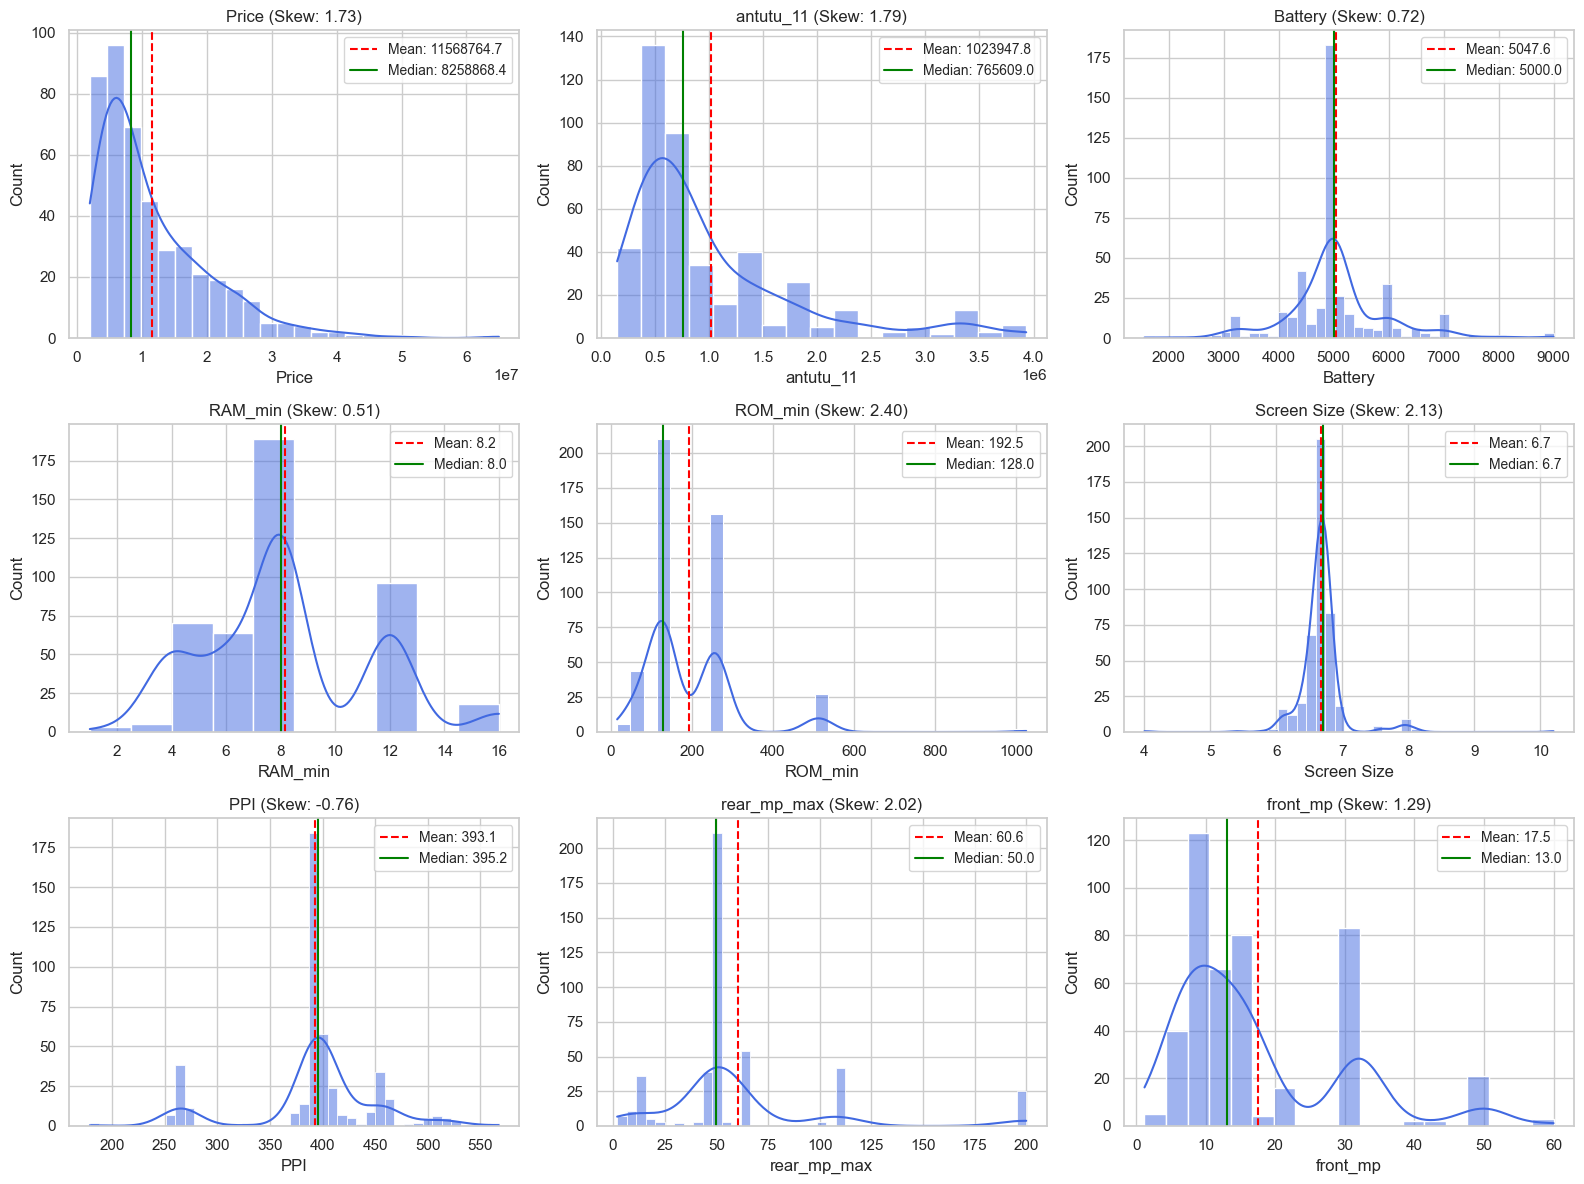

In [5]:
# --- SECTION 1: UNIVARIATE ANALYSIS ---
# Numeric Distributions
numeric_vars = ['Price', 'antutu_11', 'Battery', 'RAM_min', 'ROM_min', 'Screen Size', 'PPI', 'rear_mp_max', 'front_mp']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, var in enumerate(numeric_vars):
    sns.histplot(df[var], kde=True, ax=axes[i], color='royalblue')
    mean_val, median_val = df[var].mean(), df[var].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.1f}')
    axes[i].set_title(f'{var} (Skew: {df[var].skew():.2f})')
    axes[i].legend(fontsize='small')
plt.tight_layout()
plt.show()

Các biến như Price, antutu_11, rear_mp_max bị lệch phải nặng -> Dùng log transform cho các biến này, kỹ thuật này giúp kéo dãn các giá trị ở vùng bụng trái ra

### Horizontal Boxplot (Normalized)

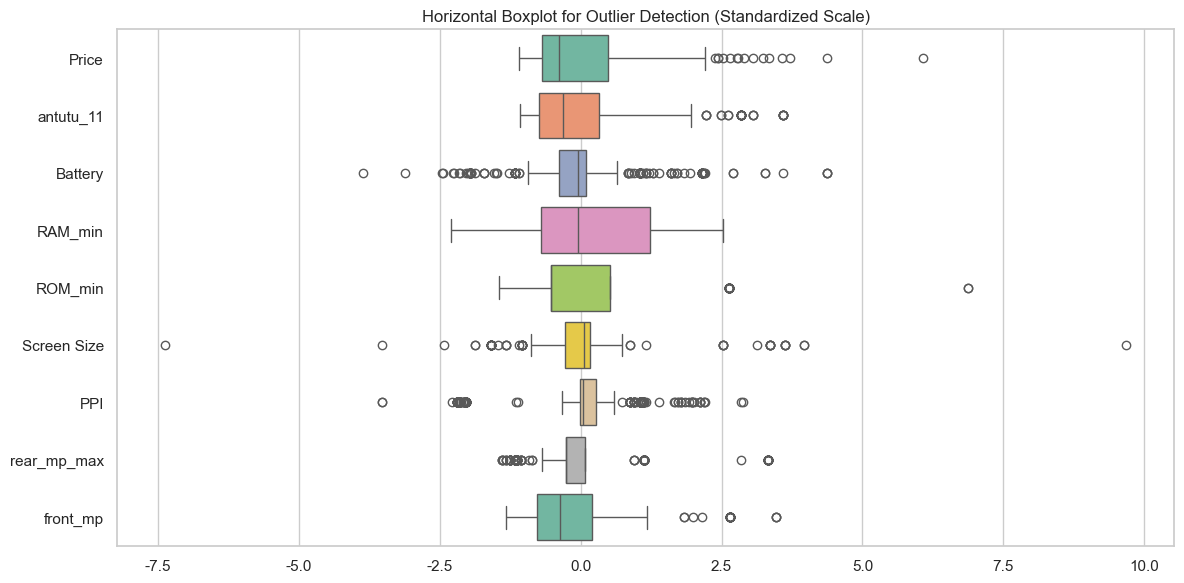

In [6]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[numeric_vars]), columns=numeric_vars)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_scaled, orient='h', palette='Set2')
plt.title("Horizontal Boxplot for Outlier Detection (Standardized Scale)")
plt.tight_layout()
plt.show()


Dựa vào kết quả này, ta cần phải tiền xử lý kết hợp giữa Log-Transform và Robust Scaler.

### Categorical Frequency

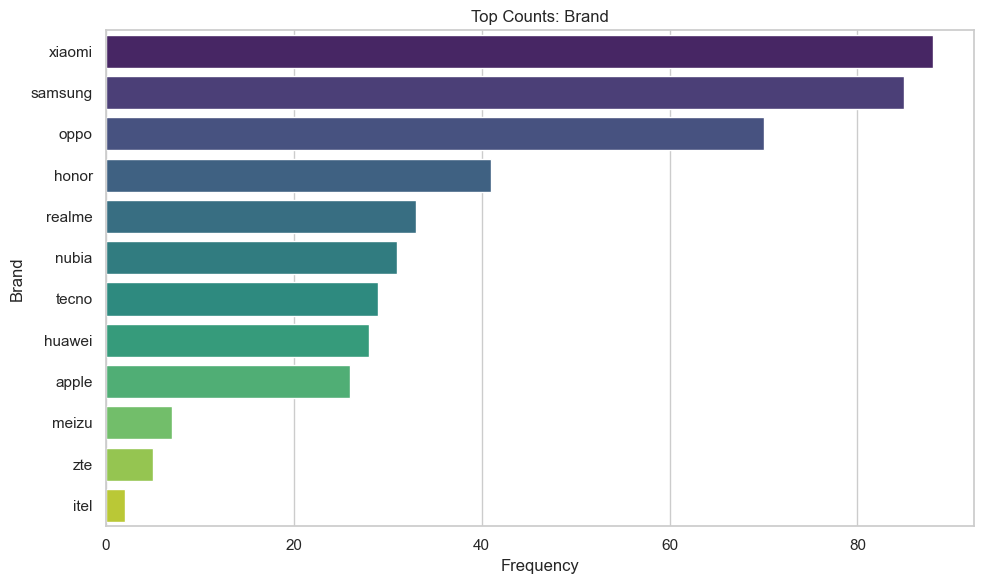

In [7]:
counts = df['Brand'].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.values, y=counts.index, palette='viridis', hue=counts.index, legend=False)
plt.title('Top Counts: Brand')
plt.xlabel('Frequency')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

Giữ lại các hãng điện thoại có số lượng > 30 làm Brand_raw, số còn lại gom thành nhóm 'Other_brand'

## SECTION 2: BIVARIATE ANALYSIS

Correlation Matrices

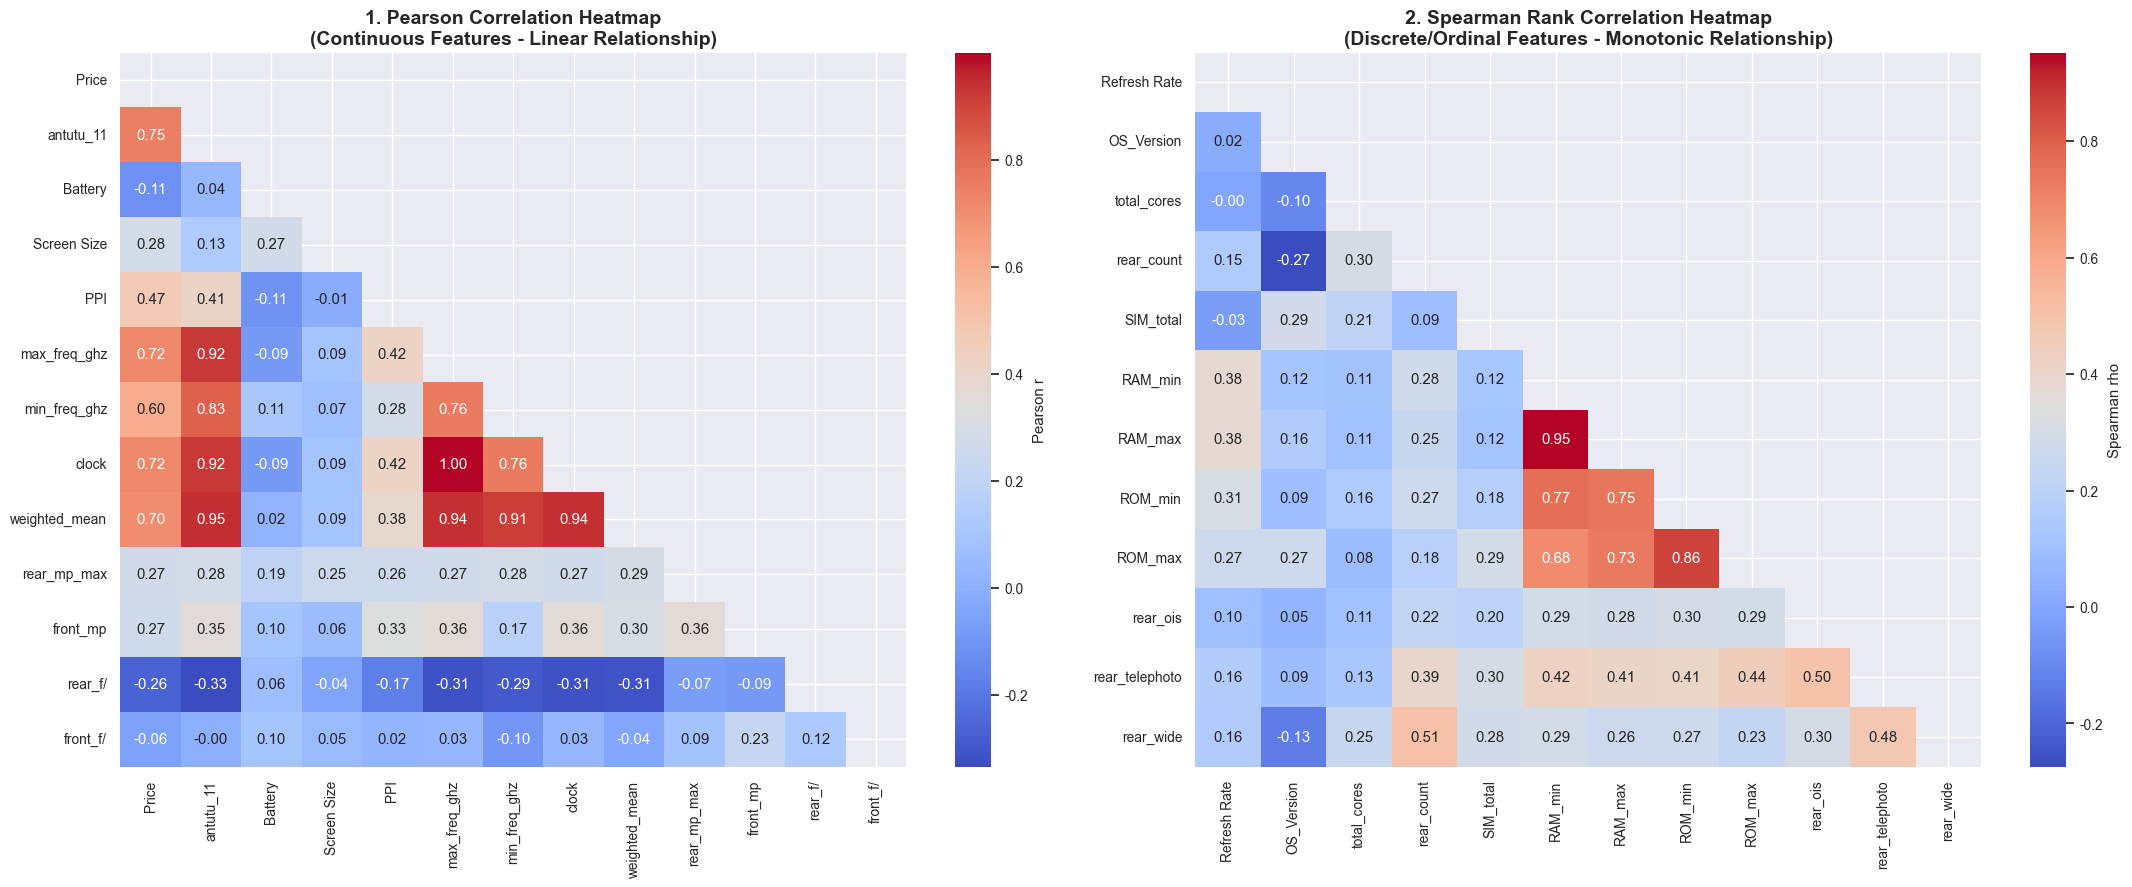


⚠️ CÁC CẶP TRÙNG LẶP NẶNG TRONG NHÓM PEARSON (LIÊN TỤC) (|value| > 0.85):
   Feature_A     Feature_B  Correlation
max_freq_ghz         clock     1.000000
   antutu_11 weighted_mean     0.945247
max_freq_ghz weighted_mean     0.941143
       clock weighted_mean     0.941127
   antutu_11         clock     0.924697
   antutu_11  max_freq_ghz     0.924674
min_freq_ghz weighted_mean     0.912694

⚠️ CÁC CẶP TRÙNG LẶP NẶNG TRONG NHÓM SPEARMAN (RỜI RẠC) (|value| > 0.85):
Feature_A Feature_B  Correlation
  RAM_min   RAM_max     0.952424
  ROM_min   ROM_max     0.862267


In [8]:
# Nhóm 1: Các biến liên tục (Continuous) -> Kiểm tra bằng Pearson
pearson_features = [
    'Price', 'antutu_11', 'Battery', 'Screen Size', 'PPI',
    'max_freq_ghz', 'min_freq_ghz', 'clock', 'weighted_mean',
    'rear_mp_max', 'front_mp', 'rear_f/', 'front_f/'
]

# Nhóm 2: Các biến rời rạc, thứ bậc, hoặc nhị phân (Discrete/Ordinal/Binary) -> Kiểm tra bằng Spearman
spearman_features = [
    'Refresh Rate', 'OS_Version', 'total_cores', 'rear_count', 'SIM_total',
    'RAM_min', 'RAM_max', 'ROM_min', 'ROM_max',
    'rear_ois', 'rear_telephoto', 'rear_wide'
]

sns.set_theme(style="darkgrid", font_scale=0.9)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

# Heatmap 1: Pearson
corr_p = df[pearson_features].corr(method='pearson')
mask_p = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap='coolwarm', mask=mask_p, ax=ax1, cbar_kws={'label': 'Pearson r'})
ax1.set_title("1. Pearson Correlation Heatmap\n(Continuous Features - Linear Relationship)", fontsize=14, fontweight='bold')

# Heatmap 2: Spearman
corr_s = df[spearman_features].corr(method='spearman')
mask_s = np.triu(np.ones_like(corr_s, dtype=bool))
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap='coolwarm', mask=mask_s, ax=ax2, cbar_kws={'label': 'Spearman rho'})
ax2.set_title("2. Spearman Rank Correlation Heatmap\n(Discrete/Ordinal Features - Monotonic Relationship)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

THRESHOLD = 0.85

def get_high_corr_pairs(corr_matrix, mask, method_name):
    upper_tri = corr_matrix.where(mask)
    pairs = (
        upper_tri.stack()
        .reset_index()
        .rename(columns={"level_0": "Feature_A", "level_1": "Feature_B", 0: "Correlation"})
    )
    # Lọc lấy các cặp có giá trị tuyệt đối lớn hơn THRESHOLD và loại bỏ tương quan với chính nó (tương quan = 1)
    high_pairs = pairs[(abs(pairs['Correlation']) > THRESHOLD) & (abs(pairs['Correlation']) < 1.0)]
    high_pairs = high_pairs.sort_values(by="Correlation", key=abs, ascending=False).reset_index(drop=True)
    
    print(f"\n⚠️ CÁC CẶP TRÙNG LẶP NẶNG TRONG NHÓM {method_name.upper()} (|value| > {THRESHOLD}):")
    if high_pairs.empty:
        print(" -> Không có cặp nào vượt ngưỡng nguy hiểm.")
    else:
        print(high_pairs.to_string(index=False))
    return high_pairs

high_pearson = get_high_corr_pairs(corr_p, mask_p, "Pearson (Liên tục)")
high_spearman = get_high_corr_pairs(corr_s, mask_s, "Spearman (Rời rạc)")

* Ở nhóm Pearson, các biến clock, weighted có tương quan mạnh với max_freq_ghz và antutu_11 -> Loại bỏ các biến nàỳ.  
* Ở nhóm, RAM_min và ROM_min tương quan mạnh với RAM_max và RAM_max -> Loại bỏ RAM_max và ROM_max


In [9]:
# Thực hiện loại bỏ các biến trùng lặp phát hiện qua Heatmap độc lập
df = df.drop(columns=['clock', 'weighted_mean', 'RAM_max', 'ROM_max'])
print(f"Đã loại bỏ 6 biến nhiễu. Số thuộc tính còn lại: {df.shape[1]}")

Đã loại bỏ 6 biến nhiễu. Số thuộc tính còn lại: 33


In [10]:
# 2. Lọc các cột dữ liệu dạng số (VIF chỉ tính được trên biến liên tục/số)
# Chúng ta loại bỏ cột dạng chuỗi (Name, Brand, OS_Name...) và các cột ID/Index không liên quan
vif_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Đảm bảo loại bỏ các cột không tham gia tính toán khoảng cách hoặc các cột nhãn nhu cầu (Need-Tags) nếu có
exclude_cols = ['Unnamed: 0', 'Price_source','suspect_imputation']
vif_features = [col for col in vif_features if col not in exclude_cols]

# Lọc dataframe chỉ giữ lại các cột cần tính VIF
# Lưu ý: Hàm variance_inflation_factor yêu cầu dữ liệu không được chứa giá trị khuyết thiếu (NaN)
X_vif = df[vif_features].dropna()

print(f"--- Bắt đầu tính VIF cho {X_vif.shape[1]} thuộc tính phần cứng ---")

# 3. Hàm tính toán chỉ số VIF
def calculate_vif(data_frame):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = data_frame.columns
    
    # Tính VIF cho từng biến i
    vif_data["VIF"] = [
        variance_inflation_factor(data_frame.values, i) 
        for i in range(data_frame.shape[1])
    ]
    
    # Sắp xếp kết quả VIF giảm dần để dễ phát hiện biến cộng tuyến nặng
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    return vif_data

# 4. Chạy hàm và hiển thị kết quả
vif_result = calculate_vif(X_vif)

print("\n=== KẾT QUẢ KIỂM ĐỊNH VIF ===")
print(vif_result.to_string())

# 5. Đưa ra gợi ý cảnh báo nhanh dựa trên ngưỡng thống kê (VIF > 10)
high_vif = vif_result[vif_result['VIF'] > 10]
if not high_vif.empty:
    print("\n⚠️ CẢNH BÁO ĐA CỘNG TUYẾN NGHIÊM TRỌNG (VIF > 10):")
    print(f"Có {len(high_vif)} biến bị trùng lặp thông tin nặng nề. Bạn nên cân nhắc xóa bỏ:")
    print(high_vif['Feature'].tolist())
else:
    print("\n✅ Tuyệt vời! Không có hiện tượng đa cộng tuyến nghiêm trọng (Tất cả VIF <= 10).")

--- Bắt đầu tính VIF cho 23 thuộc tính phần cứng ---

=== KẾT QUẢ KIỂM ĐỊNH VIF ===
           Feature         VIF
0      Screen Size  290.109780
1         front_f/  183.532460
2     max_freq_ghz  172.988007
3          rear_f/  165.892603
4     min_freq_ghz  109.588982
5              PPI   65.959589
6     Refresh Rate   54.167807
7          Battery   49.846630
8       OS_Version   49.076054
9        antutu_11   33.602051
10     total_cores   25.002533
11         RAM_min   22.984165
12      rear_count   16.297580
13           Price   10.362723
14         ROM_min    7.653808
15        front_mp    5.284214
16       SIM_total    5.249882
17     rear_mp_max    4.391579
18             NFC    4.304425
19       rear_wide    3.660712
20  rear_telephoto    3.187602
21        has_eSIM    2.204829
22        rear_ois    1.654290

⚠️ CẢNH BÁO ĐA CỘNG TUYẾN NGHIÊM TRỌNG (VIF > 10):
Có 14 biến bị trùng lặp thông tin nặng nề. Bạn nên cân nhắc xóa bỏ:
['Screen Size', 'front_f/', 'max_freq_ghz', 'rear_f/

In [11]:
df = df.drop(columns=['front_f/', 'rear_f/', 'max_freq_ghz', 'min_freq_ghz', 'total_cores'])

Scatter log(Price) vs log(antutu_11) + Regression Line

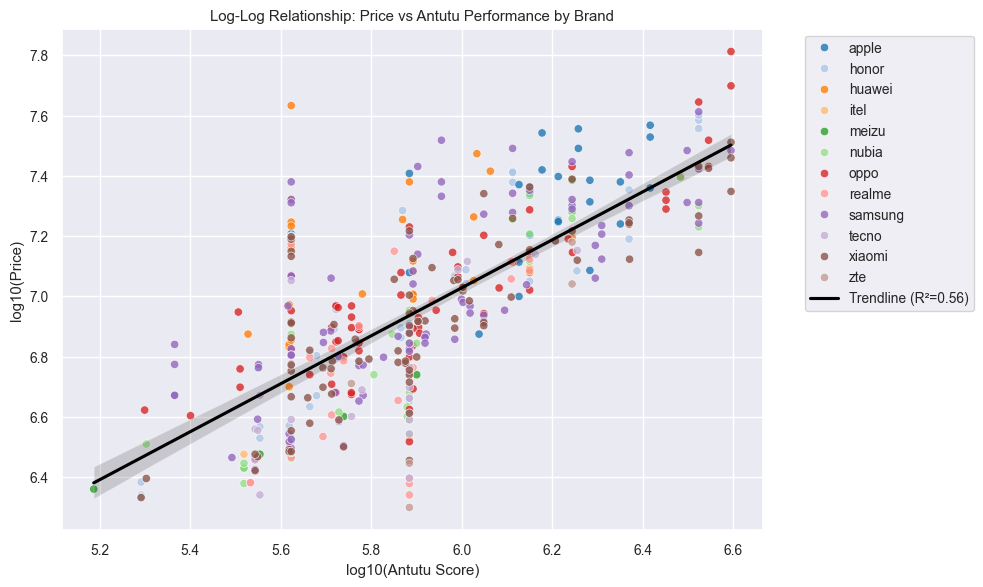

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x=np.log10(df['antutu_11']), y=np.log10(df['Price']), hue='Brand', palette='tab20', alpha=0.8)
slope, intercept, r_value, p_value, std_err = stats.linregress(np.log10(df['antutu_11']), np.log10(df['Price']))
sns.regplot(data=df, x=np.log10(df['antutu_11']), y=np.log10(df['Price']), scatter=False, color='black', label=f'Trendline (R²={r_value**2:.2f})')
plt.title("Log-Log Relationship: Price vs Antutu Performance by Brand")
plt.xlabel("log10(Antutu Score)")
plt.ylabel("log10(Price)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Residual Analysis (Brand Premium)

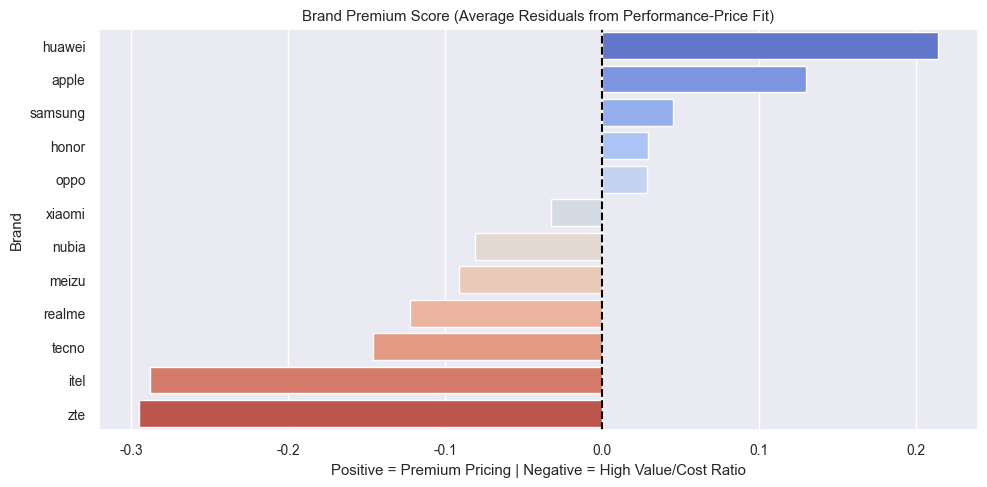

In [13]:
df['log_antutu'] = np.log10(df['antutu_11'])
df['log_price'] = np.log10(df['Price'])
res = stats.linregress(df['log_antutu'], df['log_price'])
df['Price_Residual'] = df['log_price'] - (res.intercept + res.slope * df['log_antutu'])
brand_res = df.groupby('Brand')['Price_Residual'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_res.values, y=brand_res.index, palette='coolwarm', hue=brand_res.index, legend=False)
plt.axvline(0, color='black', linestyle='--')
plt.title("Brand Premium Score (Average Residuals from Performance-Price Fit)")
plt.xlabel("Positive = Premium Pricing | Negative = High Value/Cost Ratio")
plt.tight_layout()
plt.show()

### CHIPSET DISTRIBUTION ACRROS ANTUTU_11

C:\Users\hoang\AppData\Local\Temp\ipykernel_19328\1197740249.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\hoang\AppData\Local\Temp\ipykernel_19328\1197740249.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


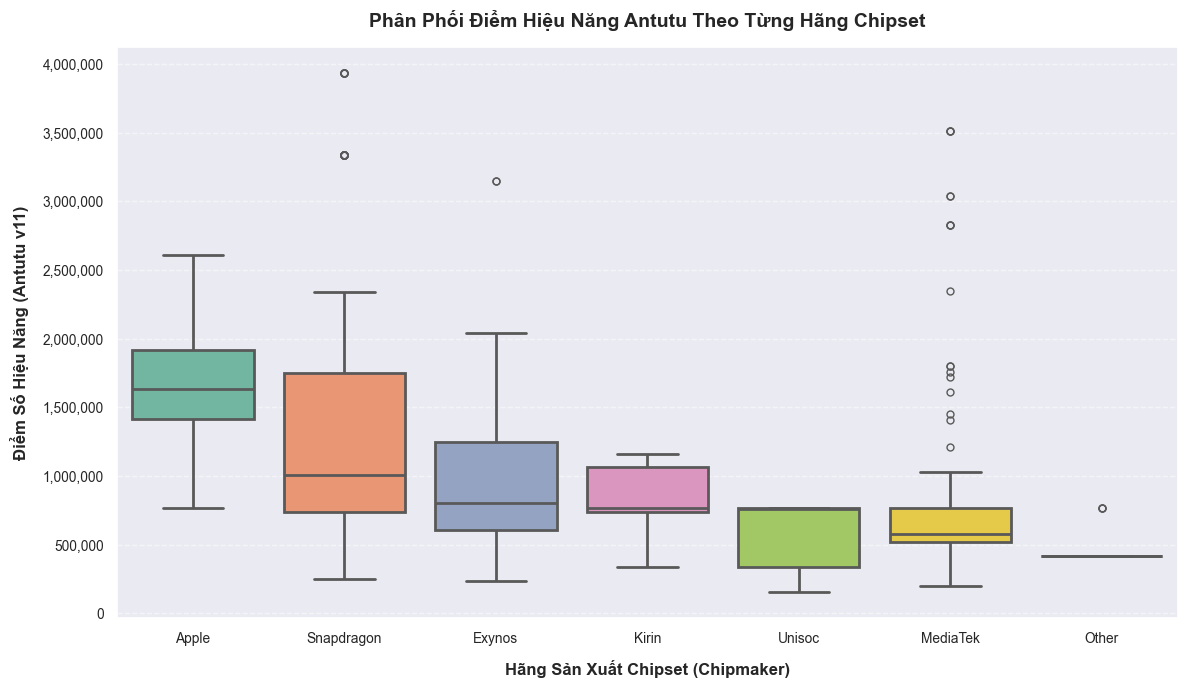

In [14]:
df_ohe = pd.get_dummies(df['Chipset_name'], prefix='Chipset_name', dtype=float)

# 3. Ghép ma trận các cột OHE mới vừa tạo ngược trở lại vào DataFrame gốc
df_final = pd.concat([df['antutu_11'], df_ohe], axis=1)

chipset_ohe_cols = [
    'Chipset_name_Apple', 'Chipset_name_Exynos', 'Chipset_name_Kirin', 
    'Chipset_name_MediaTek', 'Chipset_name_Other', 'Chipset_name_Snapdragon', 
    'Chipset_name_Unisoc'
]

available_cols = [col for col in chipset_ohe_cols if col in df_final.columns]

df['Chipset_Brand_Raw'] = df_final[available_cols].idxmax(axis=1).str.replace('Chipset_name_', '')

# 3. Tiến hành vẽ biểu đồ Boxplot Hiệu năng
plt.figure(figsize=(12, 7))

# Sắp xếp các hộp theo thứ tự Trung vị (Median) giảm dần từ trái qua phải để biểu đồ có tính phân cấp rõ rệt
box_order = df.groupby('Chipset_Brand_Raw')['antutu_11'].median().sort_values(ascending=False).index

# Vẽ Boxplot kết hợp với đường gạch mờ hiển thị phân phối
sns.boxplot(
    data=df, 
    x='Chipset_Brand_Raw', 
    y='antutu_11', 
    order=box_order,
    palette='Set2',          # Hệ màu sắc chuyên nghiệp, dịu mắt
    linewidth=2,             # Độ dày đường viền hộp
    fliersize=5              # Kích thước hiển thị các điểm Outliers (nếu có)
)

# 4. Định dạng biểu đồ chuẩn báo cáo khoa học
plt.title('Phân Phối Điểm Hiệu Năng Antutu Theo Từng Hãng Chipset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hãng Sản Xuất Chipset (Chipmaker)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Điểm Số Hiệu Năng (Antutu v11)', fontsize=12, fontweight='bold', labelpad=10)

# Định dạng lại trục tọa độ hiển thị số điểm dạng (Ví dụ: 1,500,000 thay vì 1500000) giúp dễ đọc
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.grid(axis='y', linestyle='--', alpha=0.5) # Thêm lưới ngang mờ để dễ gióng hàng điểm số
plt.tight_layout()

# 5. Hiển thị biểu đồ
plt.show()

Dựa vào kết quả này để chia các chipset_name thành các nhóm Flagship_Hardware, High_Mid_Hardware và Budget_Hardware

### MULTICOLLINEARITY ANALYSIS

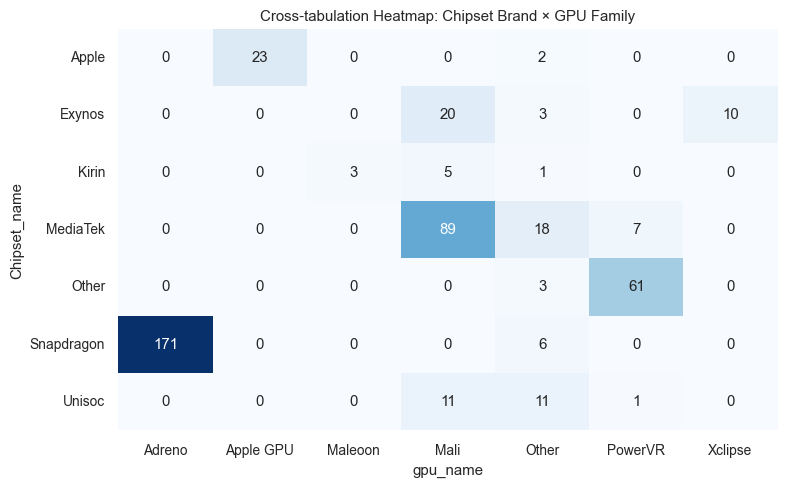

In [ ]:
plt.figure(figsize=(8, 5))
crosstab_chip_gpu = pd.crosstab(df['Chipset_name'], df['gpu_name'])
sns.heatmap(crosstab_chip_gpu, annot=True, fmt="d", cmap='Blues', cbar =False)
plt.title("Cross-tabulation Heatmap: Chipset Brand × GPU Family")
plt.tight_layout()
plt.show()

Dựa trên kết quả của biểu đồ này, quyết định loại bỏ biến gpu_name vì biến gpu_name và biến Chipset_name bị trùng lặp thông tin (Đa cộng tuyến tính)